<a href="https://colab.research.google.com/github/muraleee/oreilly-langgraph/blob/main/notebooks/4_rag_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RAG as a LangGraph Workflow

This notebook builds two LangGraph workflows:

**Part 1 — Ingestion pipeline:** Scrape real blog posts, chunk them, and embed into a Chroma vector store using an open-source embedding model. This shows LangGraph isn't just for agents — it's great for data pipelines too.

**Part 2 — RAG query workflow** with quality control:
- A **retrieve** node
- A **grade documents** node (LLM judges relevance)
- A **generate** node
- A **web search fallback** node (using SerpAPI)
- **Conditional routing** between them

We'll use real content from the [AI Office Hours](https://ai-office-hours.beehiiv.com/) blog as our knowledge base.

In [1]:
!pip install -U --quiet \
    "langchain>=1.0.0a" \
    langchain-openai \
    langchain-community \
    langgraph \
    langsmith \
    langchain-mcp-adapters \
    faiss-cpu \
    openai \
    chromadb \
    langchain-chroma \
    langchain-huggingface \
    beautifulsoup4 \
    google-search-results \
    python-dotenv \
    tiktoken \
    mcp \
    sentence-transformers \
    pandas

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 111.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.5/325.5 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 109.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 151.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 32.3 MB/s eta 0:00:00

In [2]:
from google.colab import userdata
import os
os.environ['OPENROUTER_API_KEY'] = userdata.get('OPENROUTER_API_KEY')
os.environ['SERPAPI_API_KEY'] = userdata.get('SERPAPI_API_KEY')

## Part 1: Ingestion Pipeline as a LangGraph Workflow

Most RAG tutorials skip ingestion or hardcode documents. Here we build a **real ingestion pipeline** as a LangGraph graph:

1. **Scrape** — `WebBaseLoader` fetches blog posts from [AI Office Hours](https://ai-office-hours.beehiiv.com/)
2. **Chunk** — `RecursiveCharacterTextSplitter` breaks them into retrieval-sized pieces
3. **Embed & Store** — `HuggingFaceEmbeddings` (open-source, runs locally) + Chroma vector store

This demonstrates that LangGraph graphs aren't just for agents — they're a general-purpose orchestration framework.

In [3]:
from typing import TypedDict, Any
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END

# Blog posts from https://ai-office-hours.beehiiv.com/
BLOG_URLS = [
    "https://ai-office-hours.beehiiv.com/p/evaluating-ai-agent-tool-selection",
    "https://ai-office-hours.beehiiv.com/p/beyond-benchmarks",
    "https://ai-office-hours.beehiiv.com/p/re-ranking-rag-solutions",
    "https://ai-office-hours.beehiiv.com/p/to-quantize-or-not-to-quantize",
    "https://ai-office-hours.beehiiv.com/p/probing-llms-for-a-world-model",
    "https://ai-office-hours.beehiiv.com/p/ais-supervising-ais",
]


class IngestionState(TypedDict):
    urls: list[str]
    raw_documents: list[Document]
    chunks: list[Document]
    vectorstore: Any  # Chroma instance — passed through state for downstream use


def scrape_node(state: IngestionState) -> dict:
    """Scrape blog posts using LangChain's WebBaseLoader."""
    print(f"Scraping {len(state['urls'])} URLs...")
    loader = WebBaseLoader(state["urls"])
    docs = loader.load()
    print(f"  Loaded {len(docs)} documents")
    for doc in docs:
        title = doc.metadata.get("title", "Untitled")
        print(f"  - {title[:60]} ({len(doc.page_content)} chars)")
    return {"raw_documents": docs}


def chunk_node(state: IngestionState) -> dict:
    """Split documents into retrieval-sized chunks."""
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=200,
        separators=["\n\n", "\n", ". "],
    )
    chunks = splitter.split_documents(state["raw_documents"])
    print(f"Split {len(state['raw_documents'])} documents into {len(chunks)} chunks")
    return {"chunks": chunks}


def embed_and_store_node(state: IngestionState) -> dict:
    """Embed chunks using a local open-source model and store in Chroma."""
    # all-MiniLM-L6-v2: fast, small (80MB), runs entirely on CPU — no API key needed
    embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
    vectorstore = Chroma.from_documents(
        state["chunks"],
        embeddings,
        collection_name="ai_office_hours",
    )
    print(f"Embedded and stored {len(state['chunks'])} chunks in Chroma")
    return {"vectorstore": vectorstore}


# Build the ingestion graph
ingestion_graph = StateGraph(IngestionState)
ingestion_graph.add_node("scrape", scrape_node)
ingestion_graph.add_node("chunk", chunk_node)
ingestion_graph.add_node("embed_and_store", embed_and_store_node)

ingestion_graph.add_edge(START, "scrape")
ingestion_graph.add_edge("scrape", "chunk")
ingestion_graph.add_edge("chunk", "embed_and_store")
ingestion_graph.add_edge("embed_and_store", END)

ingestion_app = ingestion_graph.compile()

### Visualize and run the ingestion pipeline

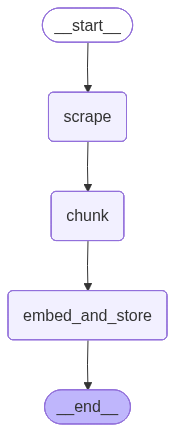

In [4]:
from IPython.display import Image, display

display(Image(ingestion_app.get_graph().draw_mermaid_png()))

### Run the ingestion pipeline

This will scrape the blog, chunk the content, and embed everything into Chroma — all orchestrated by LangGraph.

In [5]:
# Run ingestion — scrapes live blog content, chunks it, embeds with HuggingFace, stores in Chroma
result = ingestion_app.invoke({"urls": BLOG_URLS})

# Pull the vectorstore out of the graph result for use in Part 2
vectorstore = result["vectorstore"]
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

print(f"\nReady for RAG — retriever loaded with {vectorstore._collection.count()} chunks")

Scraping 6 URLs...
  Loaded 6 documents
  - Evaluating AI Agent Tool Selection (7635 chars)
  - Beyond Benchmarks (11856 chars)
  - AI Office Hours (1975 chars)
  - AI Office Hours (1981 chars)
  - AI Office Hours (1981 chars)
  - AIs Supervising AIs (5745 chars)
Split 6 documents into 40 chunks


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedded and stored 40 chunks in Chroma

Ready for RAG — retriever loaded with 40 chunks


In [ ]:
vectorstore.get()

## Part 2: RAG Query Workflow

Now that we have a real knowledge base, let's build a **RAG query graph** with quality control:

1. **Retrieve** — query the Chroma vector store
2. **Grade documents** — LLM judges whether each retrieved chunk is actually relevant
3. **Generate** — answer from relevant docs, OR
4. **Web search fallback** — if nothing is relevant, fall back to SerpAPI

The grading step is the key differentiator from naive RAG — we don't blindly trust the retriever.

In [11]:
from langchain_openai import ChatOpenAI
from langchain_community.utilities import SerpAPIWrapper
from pydantic import BaseModel, Field

llm = ChatOpenAI(
    model="openai/gpt-4.1",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
)
grading_llm = ChatOpenAI(
    model="openai/gpt-4.1-mini",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    temperature=0,
)
serpapi = SerpAPIWrapper()


class RAGState(TypedDict):
    question: str
    documents: list[Document]
    relevant_documents: list[Document]
    web_results: str
    generation: str
    docs_relevant: bool

### RAG nodes: retrieve, grade, generate, and web search fallback

In [12]:
def retrieve(state: RAGState) -> dict:
    """Query the Chroma vector store for relevant documents."""
    print(f"Retrieving documents for: {state['question']}")
    documents = retriever.invoke(state["question"])
    print(f"  Retrieved {len(documents)} documents")
    return {"documents": documents}



class GradeResult(BaseModel):
    """Binary relevance grade for a document."""
    reasoning: str = Field(description="Brief explanation of why")
    is_relevant: bool = Field(description="Whether the document is relevant to the question")


grader = grading_llm.with_structured_output(GradeResult)

def grade_documents(state: RAGState) -> dict:
    """Grade each retrieved document for relevance using an LLM judge."""
    print("Grading document relevance...")
    relevant_docs = []

    for doc in state["documents"]:
        grade = grader.invoke(
            f"Question: {state['question']}\n\n"
            f"Document: {doc.page_content}\n\n"
            f"Is this document relevant to answering the question?"
        )
        status = "RELEVANT" if grade.is_relevant else "NOT RELEVANT"
        print(f"  [{status}] {doc.page_content[:60]}... — {grade.reasoning}")
        if grade.is_relevant:
            relevant_docs.append(doc)

    docs_relevant = len(relevant_docs) > 0
    print(f"  {len(relevant_docs)}/{len(state['documents'])} documents relevant")
    return {"relevant_documents": relevant_docs, "docs_relevant": docs_relevant}


def generate(state: RAGState) -> dict:
    """Generate an answer using the relevant documents (or web results as fallback)."""
    if state.get("web_results"):
        context = state["web_results"]
        source = "web search"
    else:
        context = "\n\n".join(doc.page_content for doc in state["relevant_documents"])
        source = "vector store"

    print(f"Generating answer from {source}...")
    response = llm.invoke(
        f"Answer the question based on the following context.\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {state['question']}\n\n"
        f"Answer:"
    )
    return {"generation": response.content}


def web_search_fallback(state: RAGState) -> dict:
    """Fall back to web search when retrieved documents aren't relevant."""
    print(f"Documents not relevant — falling back to web search for: {state['question']}")
    web_content = serpapi.run(state["question"])
    print(f"  Search complete")
    return {"web_results": web_content}

### Build the RAG query graph with conditional routing

In [13]:
def route_after_grading(state: RAGState) -> str:
    """Route to generate if docs are relevant, otherwise to web search fallback."""
    if state["docs_relevant"]:
        return "generate"
    return "web_search_fallback"


# Build the RAG query graph
rag_graph = StateGraph(RAGState)

rag_graph.add_node("retrieve", retrieve)
rag_graph.add_node("grade_documents", grade_documents)
rag_graph.add_node("generate", generate)
rag_graph.add_node("web_search_fallback", web_search_fallback)

rag_graph.add_edge(START, "retrieve")
rag_graph.add_edge("retrieve", "grade_documents")

# Conditional: grade → generate OR grade → fallback → generate
rag_graph.add_conditional_edges(
    "grade_documents",
    route_after_grading,
    {
        "generate": "generate",
        "web_search_fallback": "web_search_fallback",
    },
)

rag_graph.add_edge("web_search_fallback", "generate")
rag_graph.add_edge("generate", END)

rag_app = rag_graph.compile()

### Visualize and test the RAG query graph

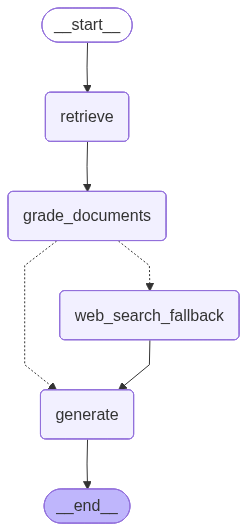

In [14]:
# The branching topology — note the conditional edge from grade_documents
display(Image(rag_app.get_graph().draw_mermaid_png()))

Test 1: A question the blog **can** answer — should retrieve relevant chunks and generate directly.

In [15]:
# Test 1: question answerable from the blog — should route directly to generate
print("=" * 60)
print("TEST 1: Question answerable from blog content")
print("=" * 60)

result = rag_app.invoke({"question": "What is positional bias in AI agents and how does it affect tool selection?"})
print(f"\nAnswer:\n{result['generation']}")

TEST 1: Question answerable from blog content
Retrieving documents for: What is positional bias in AI agents and how does it affect tool selection?
  Retrieved 3 documents
Grading document relevance...


/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=GradeResult(reasoning='Th...ion.', is_relevant=True), input_type=GradeResult])
  return self.__pydantic_serializer__.to_python(


  [RELEVANT] . Perhaps the agent selected the wrong tool twice before fum... — The document explicitly defines positional bias in AI agents as the tendency of the model to pay more attention to tokens at the start or end of the prompt while ignoring those in the middle. It also explains how this bias affects tool selection by causing tools listed in the middle of the prompt to be overlooked, impacting accuracy and latency. Therefore, it directly addresses both what positional bias is and how it affects tool selection.


/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=GradeResult(reasoning="Th...ion.", is_relevant=True), input_type=GradeResult])
  return self.__pydantic_serializer__.to_python(


  [RELEVANT] . so a 9.51% in the first bar means that on average, the LLM... — The document explicitly discusses positional bias in AI agents, explaining that models tend to over-select tools listed earlier in a list, even when those tools are not the correct choice. It also mentions that this bias affects tool selection across different models, including OpenAI's. Therefore, it directly addresses what positional bias is and how it impacts tool selection.


/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=GradeResult(reasoning="Th...ts.", is_relevant=False), input_type=GradeResult])
  return self.__pydantic_serializer__.to_python(


  [NOT RELEVANT] . Your Basic AI Agent relies on an auto-regressive LLM‚Äôs a... — The document discusses the importance of an AI agent selecting the right tool at the right time and mentions challenges in tool selection, but it does not define or explain 'positional bias' or how it specifically affects tool selection. Therefore, it is not directly relevant to the question about positional bias in AI agents.
  2/3 documents relevant
Generating answer from vector store...

Answer:
**Positional bias** in AI agents, particularly those built on transformer-based large language models (LLMs), is a tendency for the model to pay more attention to items (tokens or options) that appear at the **start or end** of a prompt while **overlooking those in the middle**. This phenomenon is often referred to as the "lost-in-the-middle" problem.

**How it affects tool selection:**
- When an AI agent is prompted with a list of tools to choose from, **tools listed at the beginning (earlier indexes) or end 

In [16]:
# Test 2: question the blog CANNOT answer — should trigger web search fallback
print("=" * 60)
print("TEST 2: Question requiring web search fallback")
print("=" * 60)

result = rag_app.invoke({"question": "What are the latest features in LangGraph??"})
print(f"\nAnswer:\n{result['generation']}")

TEST 2: Question requiring web search fallback
Retrieving documents for: What are the latest features in LangGraph??
  Retrieved 3 documents
Grading document relevance...


/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=GradeResult(reasoning="Th...es.", is_relevant=False), input_type=GradeResult])
  return self.__pydantic_serializer__.to_python(


  [NOT RELEVANT] .  Other topics in the session will include:  The path to ‚Ä... — The document discusses topics related to AI benchmarking, AGI, and AI evaluation but does not mention LangGraph or its latest features. Therefore, it does not provide information relevant to the question about LangGraph's latest features.
  [NOT RELEVANT] . Biases and shortcuts: Static benchmarks often contain arti... — The document discusses AI benchmarks and their limitations but does not mention LangGraph or its latest features. Therefore, it does not provide information relevant to the question about LangGraph's latest features.


/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=GradeResult(reasoning='Th...ph.', is_relevant=False), input_type=GradeResult])
  return self.__pydantic_serializer__.to_python(


  [NOT RELEVANT] . Someone (or usually some people) create and propose a test... — The document discusses benchmarks for large language models (LLMs) and their role in evaluating model performance. However, it does not mention LangGraph or any features related to it, nor does it provide information about the latest features in LangGraph.
  0/3 documents relevant
Documents not relevant — falling back to web search for: What are the latest features in LangGraph??
  Search complete
Generating answer from web search...

Answer:
Based on the provided context, the latest features in **LangGraph** include:

- **Durable execution**: Ensures reliability and robustness for long-running agents and workflows.
- **Streaming**: Allows real-time data processing and output, enhancing responsiveness in agent interactions.
- **Human oversight**: Facilitates human-in-the-loop control and supervision for more secure and accurate workflows.
- **Memory**: Built-in memory stores conversation histories and ma

## Exercise: Add a self-correction loop

> **Exercise:** Add a **quality check** after the `generate` node. Use an LLM to check whether the generated answer is actually grounded in the context. If it's not (hallucination detected), route back to `web_search_fallback` for a second attempt.
>
> Test with:
> - `"What is positional bias in tool selection?"` → should generate from blog content and pass the quality check
> - `"What are the latest features in Python 3.14?"` → might hallucinate from blog context and trigger the self-correction loop
>
> Hints:
> - Add a `check_answer` node after `generate` that uses `with_structured_output` to assess groundedness
> - Add a conditional edge from `check_answer` → END (if grounded) or → `web_search_fallback` (if not)
> - Be careful about infinite loops — add a `retry_count` field to state and limit retries

In [ ]:
# YOUR CODE HERE
